**Mount Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Libraries**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.metrics import mean_squared_error, mean_absolute_error

**Load Sequence Data**

In [5]:
BASE_PATH = "/content/drive/MyDrive/c01-price-forecasting/data/model_inputs/lstm/"

X_train = np.load(BASE_PATH + "X_train_seq.npy")
X_test = np.load(BASE_PATH + "X_test_seq.npy")
y_train = np.load(BASE_PATH + "y_train_seq.npy")
y_test = np.load(BASE_PATH + "y_test_seq.npy")

print("Loaded LSTM data ✅")
print("X_train shape:", X_train.shape)

Loaded LSTM data ✅
X_train shape: (1812, 8, 20)


**Shape Check**

In [6]:
print("Expected shape: (samples, timesteps, features)")

Expected shape: (samples, timesteps, features)


**Build LSTM Model**

In [13]:
from keras.models import Sequential
from keras.layers import Input, LSTM, Dropout, Dense

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1),
])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 8, 64)          │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

 Non-trainable params: 0 (0.00 B)

**Compile Model**

In [14]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

**Confirm Build**

In [15]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 8, 64)          │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0148 - mae: 0.0871 - val_loss: 0.0059 - val_mae: 0.0651
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0049 - mae: 0.0510 - val_loss: 0.0140 - val_mae: 0.1079
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0042 - mae: 0.0468 - val_loss: 0.0042 - val_mae: 0.0465
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0039 - mae: 0.0447 - val_loss: 0.0092 - val_mae: 0.0862
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0033 - mae: 0.0419 - val_loss: 0.0039 - val_mae: 0.0486
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0033 - mae: 0.0408 - val_loss: 0.0036 - val_mae: 0.0422
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0029 - mae: 0.0388 - val_loss: 0.0032 - val_mae: 0.0416
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028 - mae: 0.0380 - val_loss: 0.0035 - val_mae: 0.0478
Epoch 9/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.002

**Predictions**

In [17]:
y_pred = model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


**Inverse Scaling**

In [20]:
import joblib
import numpy as np

# Load scaler
scaler = joblib.load("/content/drive/MyDrive/c01-price-forecasting/data/model_inputs/lstm/scaler.pkl")

# Reconstruct shape
n_features = X_train.shape[2]

y_pred_full = np.zeros((len(y_pred), n_features + 1))
y_test_full = np.zeros((len(y_test), n_features + 1))

# Insert values
y_pred_full[:, -1] = y_pred.flatten()
y_test_full[:, -1] = y_test.flatten()

# Inverse transform
y_pred_inv = scaler.inverse_transform(y_pred_full)[:, -1]
y_test_inv = scaler.inverse_transform(y_test_full)[:, -1]

print("Inverse scaling completed ✅")

Inverse scaling completed ✅


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print("\nCorrected LSTM Results:")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)


Corrected LSTM Results:
RMSE: 6.838989736739883
MAE: 4.977774385304915
MAPE: 4.239021947506151


**Evaluation**

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n📊 LSTM Results:")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)


📊 LSTM Results:
RMSE: 0.05232585873557677
MAE: 0.03808549644456707
MAPE: 9.276503005733803


**Plot**

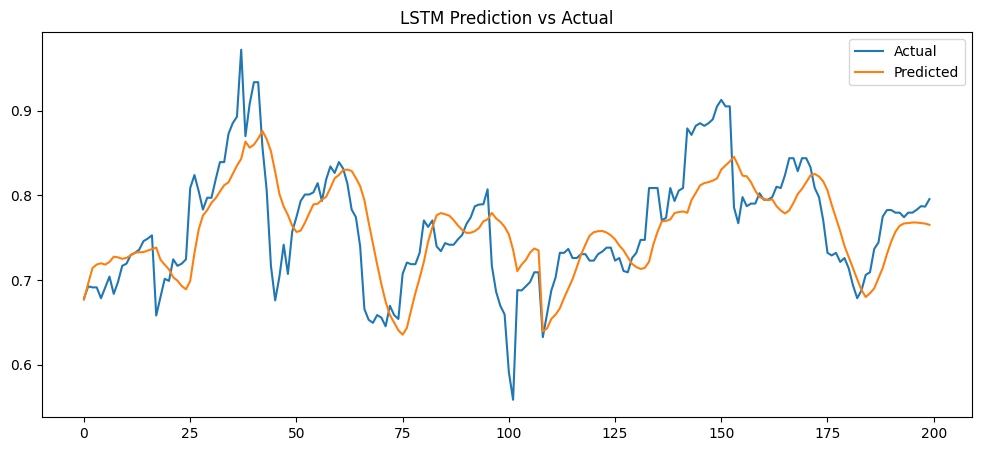

In [19]:
plt.figure(figsize=(12,5))

plt.plot(y_test[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")

plt.legend()
plt.title("LSTM Prediction vs Actual")
plt.show()